In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_PATH = Path("../../../..") / "data" / "processed" / "indices_panel.csv"


In [2]:
df = pd.read_csv(DATA_PATH)
df.head()

,date,timestamp,symbol,open,high,low,close,volume,trade_count,vwap
0,2020-07-27,2020-07-27T04:00:00Z,QQQ,248.06,251.26,247.38,250.87,289367,1950,249.72
1,2020-07-27,2020-07-27T04:00:00Z,SPY,296.85,298.48,296.11,298.36,647693,4768,297.65
2,2020-07-28,2020-07-28T04:00:00Z,QQQ,250.33,250.53,247.42,247.69,209178,1679,249.17
3,2020-07-28,2020-07-28T04:00:00Z,SPY,297.72,298.71,296.14,296.50,521475,4238,297.59
4,2020-07-29,2020-07-29T04:00:00Z,QQQ,249.17,251.37,248.82,250.62,177841,1332,250.19


In [3]:
df.tail()

,date,timestamp,symbol,open,high,low,close,volume,trade_count,vwap
2861,2026-04-07,2026-04-07T04:00:00Z,SPY,656.850,659.54,651.06,659.23,1811115,20850,655.731737
2862,2026-04-08,2026-04-08T04:00:00Z,QQQ,608.755,609.85,602.29,605.96,672900,9274,605.534652
2863,2026-04-08,2026-04-08T04:00:00Z,SPY,676.400,677.06,671.55,676.00,2148131,30919,674.797963
2864,2026-04-09,2026-04-09T04:00:00Z,QQQ,606.000,610.50,603.05,610.05,650838,10233,607.993550
2865,2026-04-09,2026-04-09T04:00:00Z,SPY,674.980,681.10,673.80,679.87,1394539,20921,678.150489


In [4]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["symbol", "date"])

window_size = 200

df["SMA"] = (
    df.groupby("symbol")["close"]
    .transform(lambda s: s.rolling(window=window_size).mean())
)


In [5]:
df["SMA"]

0             NaN
2             NaN
4             NaN
6             NaN
8             NaN
          ...    
2935    678.62965
2937    679.22455
2939    679.82465
2941    680.40515
2943    681.00115
Name: SMA, Length: 2944, dtype: float64

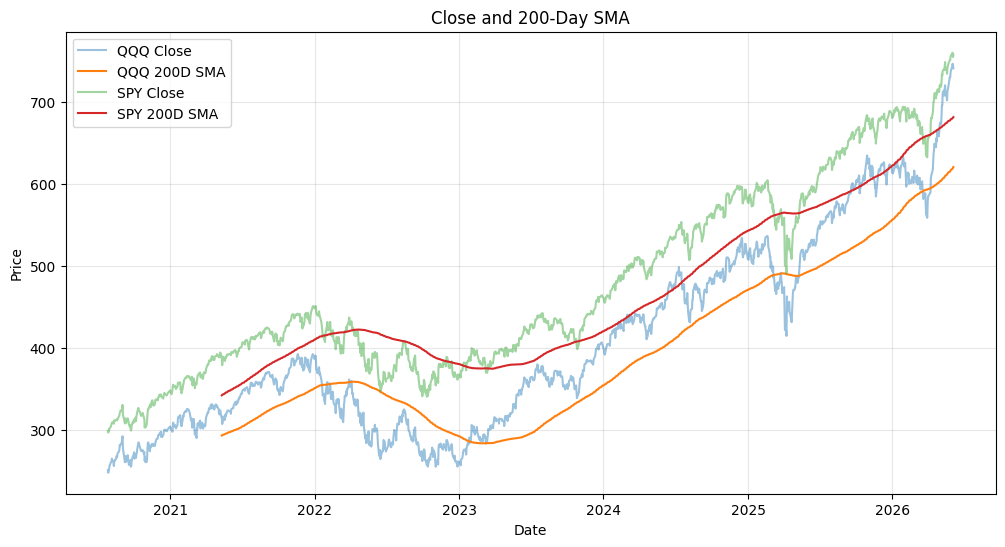

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

for symbol, symbol_df in df.groupby("symbol"):
    ax.plot(symbol_df["date"], symbol_df["close"], label=f"{symbol} Close", alpha=0.45)
    ax.plot(symbol_df["date"], symbol_df["SMA"], label=f"{symbol} {window_size}D SMA")

ax.set_title("Close and 200-Day SMA")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()
